In [22]:
import os
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import importlib
import model
importlib.reload(model)
from model import SLRHybridModel



In [23]:

CONFIG = {
    "num_classes": 353,
    "batch_size": 32,
    "input_dim": 99,
    "hidden_dim": 128,
    "data_dir": "../../ssl400_processed_paper",
    "model_path": "best_hybrid_model.pt"
}


Evaluating on: cpu
Running inference on test set...
FINAL TEST ACCURACY: 60.9777%
Classification Report 
FINAL TEST ACCURACY: 60.9777%
Classification Report 


/mnt/Data/My Files/newDetector/sign-language-detector/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/Data/My Files/newDetector/sign-language-detector/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/Data/My Files/newDetector/sign-language-detector/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

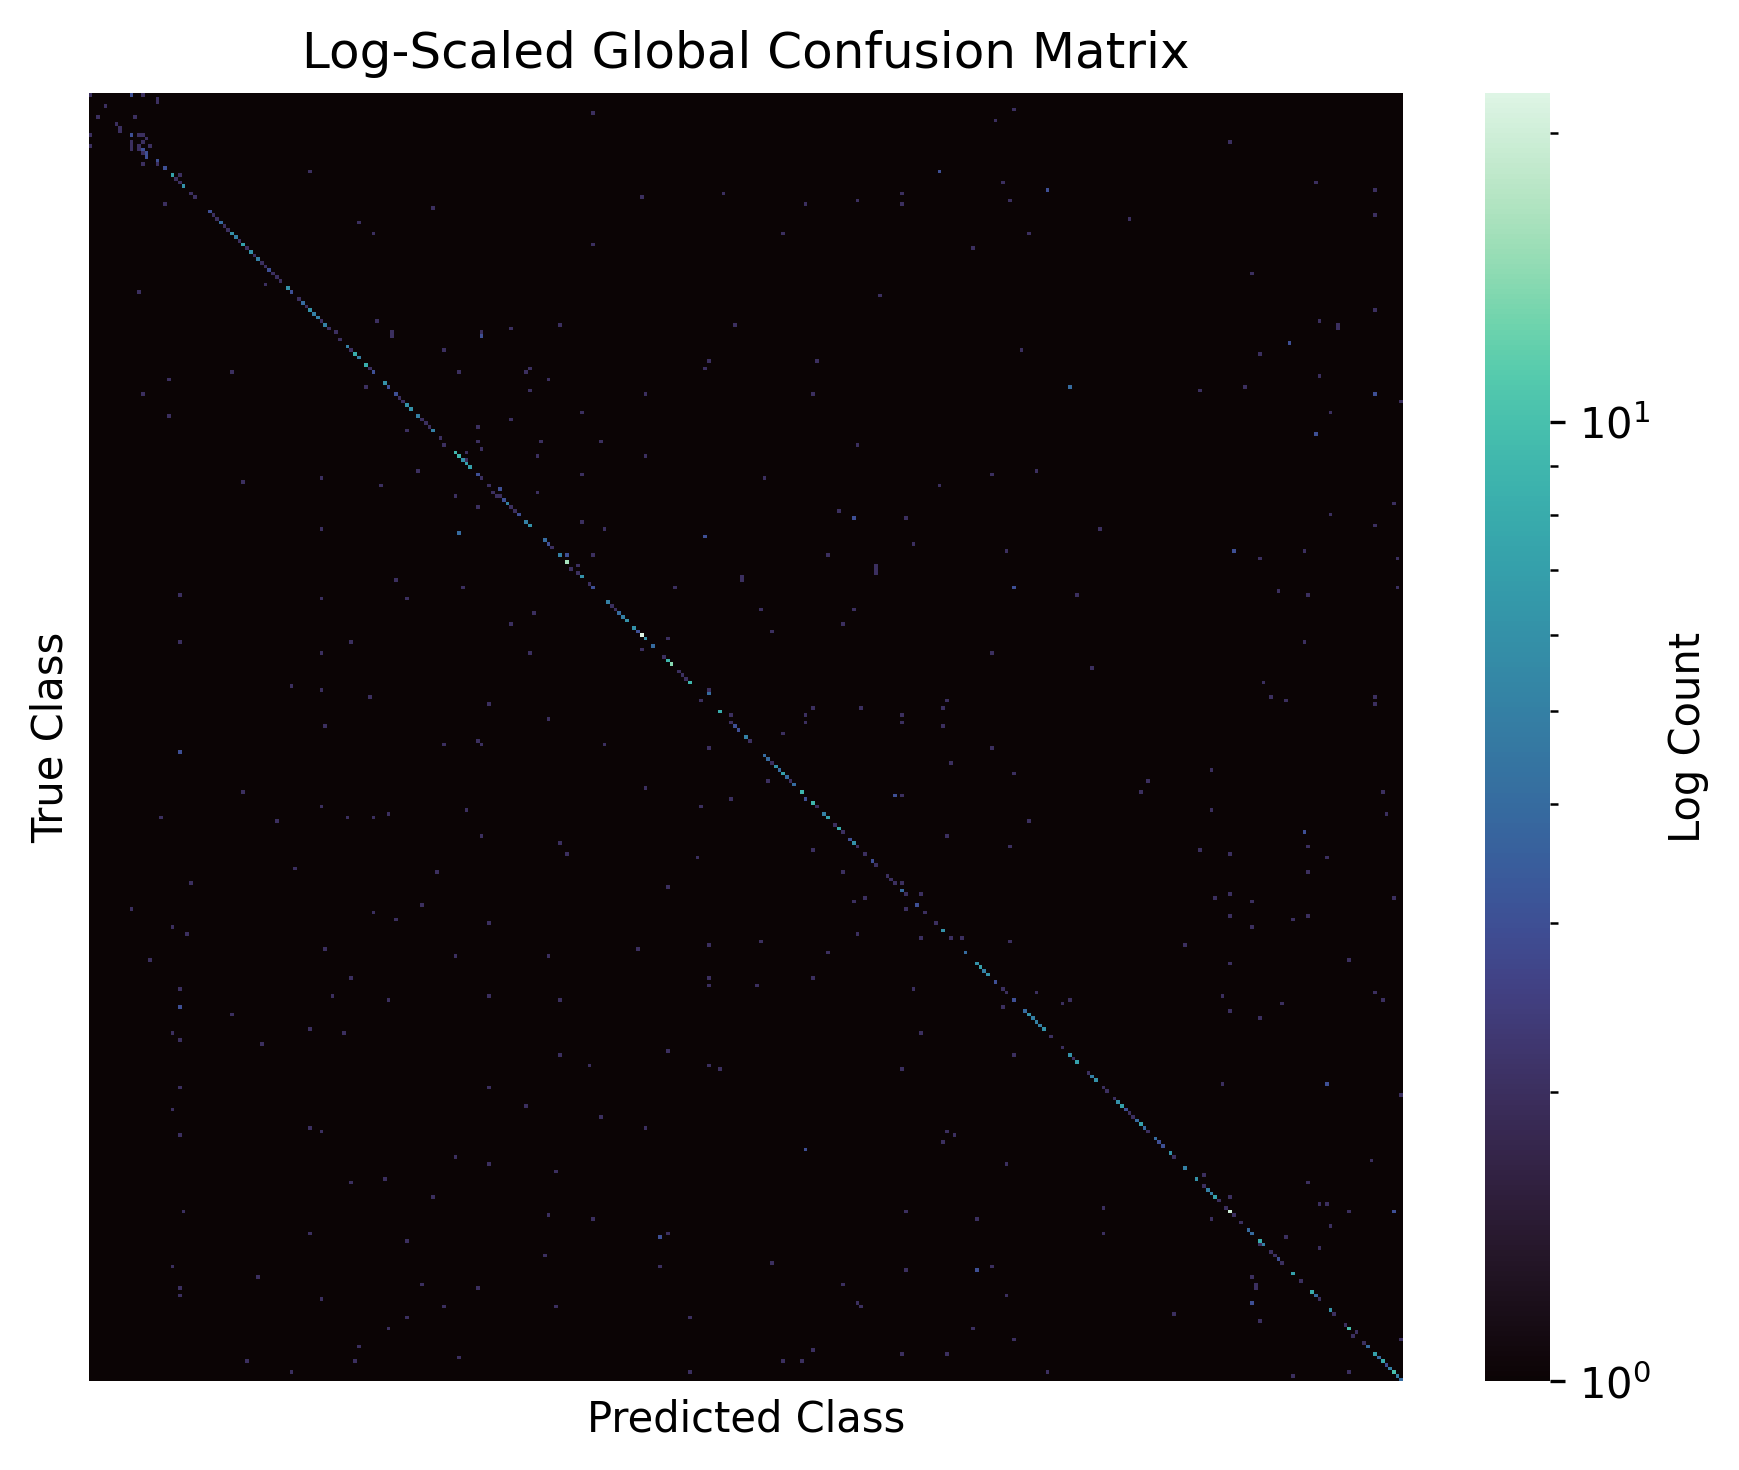

<Figure size 640x480 with 0 Axes>

In [24]:
import os
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns

import importlib
import model
importlib.reload(model)
from model import SLRHybridModel

CONFIG = {
    "num_classes": 353,
    "batch_size": 32,
    "input_dim": 99,
    "hidden_dim": 128,
    "data_dir": "../../ssl400_processed_paper",
    "model_path": "best_hybrid_model.pt"
}

@torch.no_grad()
def evaluate_model():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Evaluating on: {device}")

    test_path = os.path.join(CONFIG["data_dir"], "test_data.npz")
    label_path = os.path.join(CONFIG["data_dir"], "label_classes.npy")
    
    test_data = np.load(test_path)
    X_test = torch.from_numpy(test_data["X"]).float()
    y_test = torch.from_numpy(test_data["y"]).long()
    class_names = np.load(label_path, allow_pickle=True)

    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=CONFIG["batch_size"])

    model_instance = SLRHybridModel(CONFIG["num_classes"], CONFIG["input_dim"], CONFIG["hidden_dim"]).to(device)
    
    if not os.path.exists(CONFIG["model_path"]):
        print(f"Error: Model file {CONFIG['model_path']} not found!")
        return

    model_instance.load_state_dict(torch.load(CONFIG["model_path"], map_location=device))
    model_instance.eval()

    all_preds = []
    all_targets = []
    
    print("Running inference on test set...")
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        outputs = model_instance(X)
        preds = outputs.argmax(dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y.cpu().numpy())

    accuracy = (np.array(all_preds) == np.array(all_targets)).mean()
    
    print(f"FINAL TEST ACCURACY: {accuracy:.4%}")
    

    unique_ids = np.unique(all_targets)
    present_class_names = [str(class_names[i]) for i in unique_ids]

    report = classification_report(
        all_targets, 
        all_preds, 
        target_names=present_class_names, 
        digits=4
    )
    
    print("Classification Report ")

    with open("test_results.txt", "w") as f:
        f.write(f"Final Test Accuracy: {accuracy:.4%}\n\n")
        f.write(report)

    cm = confusion_matrix(all_targets, all_preds)
    
    
    plt.figure(figsize=(6, 5), dpi=300)
    
    sns.heatmap(cm + 1, norm=LogNorm(), cmap="mako", 
                xticklabels=False, yticklabels=False, cbar_kws={'label': 'Log Count'})
    
    plt.title("Log-Scaled Global Confusion Matrix", fontsize=12)
    plt.xlabel("Predicted Class", fontsize=10)
    plt.ylabel("True Class", fontsize=10)
    plt.tight_layout()
    plt.show()

    
    
   
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    evaluate_model()